# GPU vs Cerebras Sparse Finetuning Analysis

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

ROOT = Path.cwd() / ".."
TABLES = ROOT / "tables"

GPU_ACC_PATH = TABLES / "run_gpu_sparse_acc.csv"
GPU_TP_PATH = TABLES / "run_gpu_sparse_tp_scale.csv"
CS_ACC_PATH = TABLES / "run_cerebras_sparse_results_by_task.csv"
CS_TP_PATH = TABLES / "run_cerebras_sparse_throughput_estimates_by_batch_size.csv"

for path in [GPU_ACC_PATH, GPU_TP_PATH, CS_ACC_PATH, CS_TP_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

gpu_acc_raw = pd.read_csv(GPU_ACC_PATH)
gpu_tp_raw = pd.read_csv(GPU_TP_PATH)
cs_acc_raw = pd.read_csv(CS_ACC_PATH)
cs_tp_raw = pd.read_csv(CS_TP_PATH)

display(Markdown(
    f"Loaded `{GPU_ACC_PATH.name}` ({len(gpu_acc_raw)} rows), "
    f"`{GPU_TP_PATH.name}` ({len(gpu_tp_raw)} rows), "
    f"`{CS_ACC_PATH.name}` ({len(cs_acc_raw)} rows), and "
    f"`{CS_TP_PATH.name}` ({len(cs_tp_raw)} rows)."
))

Loaded `run_gpu_sparse_acc.csv` (30 rows), `run_gpu_sparse_tp_scale.csv` (72 rows), `run_cerebras_sparse_results_by_task.csv` (54 rows), and `run_cerebras_sparse_throughput_estimates_by_batch_size.csv` (54 rows).

## 1) Reference Hardware Table

This is a compact reference table for presentation purposes. Some values are commonly cited peak or representative specs and should be treated as summary-level hardware notes rather than a procurement datasheet.

In [5]:
hardware_specs = pd.DataFrame([
    {
        "Device": "Cerebras CS-3",
        "Processor": "Wafer-Scale Engine 3 (WSE-3)",
        "On-device memory": "44 GB SRAM",
        "Compute summary": "~125 PFLOPS AI compute (sparse, vendor-cited)",
        "Core / compute units": "~900,000 AI-optimized cores",
        "Memory bandwidth": "~21 PB/s on-wafer fabric bandwidth",
        "Form factor note": "Single CS-3 system appliance"
    },
    {
        "Device": "NVIDIA A100 40 GB",
        "Processor": "Ampere GA100",
        "On-device memory": "40 GB HBM2",
        "Compute summary": "Up to ~312 TFLOPS Tensor Core (FP16/BF16 with sparsity)",
        "Core / compute units": "6912 CUDA cores, 432 Tensor Cores",
        "Memory bandwidth": "Up to ~1.6 TB/s",
        "Form factor note": "PCIe/SXM variants exist"
    }
])

hardware_specs

,Device,Processor,On-device memory,Compute summary,Core / compute units,Memory bandwidth,Form factor note
0,Cerebras CS-3,Wafer-Scale Engine 3 (WSE-3),44 GB SRAM,"~125 PFLOPS AI compute (sparse, vendor-cited)","~900,000 AI-optimized cores",~21 PB/s on-wafer fabric bandwidth,Single CS-3 system appliance
1,NVIDIA A100 40 GB,Ampere GA100,40 GB HBM2,Up to ~312 TFLOPS Tensor Core (FP16/BF16 with ...,"6912 CUDA cores, 432 Tensor Cores",Up to ~1.6 TB/s,PCIe/SXM variants exist


## Common Data Prep

The helpers below normalize model names, training-mode labels, task metrics, and throughput units so the plotting cells stay small.

In [7]:
TASK_METRIC_MAP = {
    "boolq": "acc_none",
    "hellaswag": "acc_norm_none",
    "gsm8k": "exact_match_flexible_extract",
}

MODEL_MAP = {
    "llama3.1-8b": "llama3",
    "llama3": "llama3",
    "mistral-7b": "mistral",
    "mistral": "mistral",
    "mixtral": "mixtral",
    "mixtral-8x7b": "mixtral",
}

MODE_MAP = {
    "sparse_to_dense": "Sparse to Dense",
    "sparse_to_sparse": "Sparse to Sparse",
    "sparse to dense": "Sparse to Dense",
    "sparse to sparse": "Sparse to Sparse",
}


def normalize_model(value: str) -> str:
    return MODEL_MAP.get(value, value)


def normalize_mode(value: str) -> str:
    return MODE_MAP.get(value, value)

def format_batch_label(series):
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric.apply(lambda v: f"batch={int(v)}" if pd.notna(v) else "batch=unknown")

def build_gpu_accuracy_frame(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        metric_col = TASK_METRIC_MAP[row["task"]]
        metric_value = row.get(metric_col)
        if pd.isna(metric_value):
            continue
        rows.append({
            "device": "GPU",
            "task": row["task"],
            "sparsity": row["sparsity_fraction"],
            "metric_pct": float(metric_value) * 100.0,
            "training_mode": normalize_mode(row["method"]),
            "model": normalize_model(row["model"]),
            "run_id": row["run_id"],
        })
    return pd.DataFrame(rows)


def build_cs_accuracy_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.rename(columns={
        "Task Name": "task",
        "Sparsity Percentage": "sparsity",
        "Evaluation Accuracy": "metric_raw",
        "Training Mode": "training_mode",
        "Model Name": "model",
        "Run Identifier": "run_id",
    }).copy()
    out["device"] = "Cerebras"
    out["metric_pct"] = out["metric_raw"].astype(float) * 100.0
    out["training_mode"] = out["training_mode"].map(normalize_mode)
    out["model"] = out["model"].map(normalize_model)
    return out[["device", "task", "sparsity", "metric_pct", "training_mode", "model", "run_id"]]


def build_gpu_final_throughput_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["global_batch_size"] = out["micro_batch"] * out["world_size"]
    out["samples_per_s"] = out["tokens_per_s"] / out["seq_len"]
    idx = out.groupby("run_id")["micro_batch"].idxmax()
    final_points = out.loc[idx].copy()
    final_points["device"] = "GPU"
    final_points["training_mode"] = final_points["method"].map(normalize_mode)
    final_points["model"] = final_points["model"].map(normalize_model)
    final_points["batch_label"] = "batch=" + final_points["global_batch_size"].astype(int).astype(str)
    return final_points[
        [
            "device", "task", "sparsity_fraction", "samples_per_s",
            "training_mode", "model", "batch_label", "run_id"
        ]
    ].rename(columns={"sparsity_fraction": "sparsity"})


def build_cs_final_throughput_frame(df):
    out = df.rename(
        columns={
            "Task Name": "task",
            "Sparsity Percentage": "sparsity",
            "Observed Training Throughput at Batch Size 256 (Samples Per Second)": "samples_per_s",
            "Training Mode": "training_mode",
            "Model Name": "model",
            "Run Identifier": "run_id",
            "Observed Batch Size": "batch_size",
        }
    ).copy()
    out["device"] = "Cerebras"
    out["training_mode"] = out["training_mode"].map(normalize_mode)
    out["model"] = out["model"].map(normalize_model)
    out["batch_label"] = format_batch_label(out["batch_size"])
    return out[
        ["device", "task", "sparsity", "samples_per_s", "training_mode", "model", "batch_label", "run_id"]
    ]


def build_gpu_scaling_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["batch_size"] = out["micro_batch"] * out["world_size"]
    out["samples_per_s"] = out["tokens_per_s"] / out["seq_len"]
    out["device"] = "GPU"
    out["training_mode"] = out["method"].map(normalize_mode)
    out["model"] = out["model"].map(normalize_model)
    return out[
        [
            "device", "task", "sparsity_fraction", "batch_size",
            "samples_per_s", "training_mode", "model", "run_id"
        ]
    ].rename(columns={"sparsity_fraction": "sparsity"})


def build_cs_scaling_frame(df: pd.DataFrame) -> pd.DataFrame:
    batch_cols = {
        32: "Estimated Training Throughput at Batch Size 32 (Samples Per Second, Linear Estimate)",
        64: "Estimated Training Throughput at Batch Size 64 (Samples Per Second, Linear Estimate)",
        128: "Estimated Training Throughput at Batch Size 128 (Samples Per Second, Linear Estimate)",
        256: "Estimated Training Throughput at Batch Size 256 (Samples Per Second, Linear Estimate)",
    }

    renamed = df.rename(columns={
        "Task Name": "task",
        "Sparsity Percentage": "sparsity",
        "Training Mode": "training_mode",
        "Model Name": "model",
        "Run Identifier": "run_id",
    }).copy()

    rows = []
    for _, row in renamed.iterrows():
        for batch_size, col in batch_cols.items():
            rows.append({
                "device": "Cerebras",
                "task": row["task"],
                "sparsity": row["sparsity"],
                "batch_size": batch_size,
                "samples_per_s": row[col],
                "training_mode": normalize_mode(row["training_mode"]),
                "model": normalize_model(row["model"]),
                "run_id": row["run_id"],
            })

    return pd.DataFrame(rows)


gpu_acc_plot = build_gpu_accuracy_frame(gpu_acc_raw)
cs_acc_plot = build_cs_accuracy_frame(cs_acc_raw)
acc_plot = pd.concat([gpu_acc_plot, cs_acc_plot], ignore_index=True)

gpu_final_tp_plot = build_gpu_final_throughput_frame(gpu_tp_raw)
cs_final_tp_plot = build_cs_final_throughput_frame(cs_acc_raw)
final_tp_plot = pd.concat([gpu_final_tp_plot, cs_final_tp_plot], ignore_index=True)

gpu_scaling_plot = build_gpu_scaling_frame(gpu_tp_raw)
cs_scaling_plot = build_cs_scaling_frame(cs_tp_raw)
scaling_plot = pd.concat([gpu_scaling_plot, cs_scaling_plot], ignore_index=True)

common_models = sorted(set(gpu_acc_plot["model"]) & set(cs_acc_plot["model"]))
acc_plot = acc_plot[acc_plot["model"].isin(common_models)].copy()
final_tp_plot = final_tp_plot[final_tp_plot["model"].isin(common_models)].copy()
scaling_plot = scaling_plot[scaling_plot["model"].isin(common_models)].copy()

display(Markdown(
    f"Common model families included in cross-device plots: `{', '.join(common_models)}`"
))

Common model families included in cross-device plots: `llama3, mistral`

## 2) Accuracy by Task, Sparsity, and Device

Rows are tasks. Columns are device types. The y-axis is percent performance and is shared within each task row (not forced to 0-100).

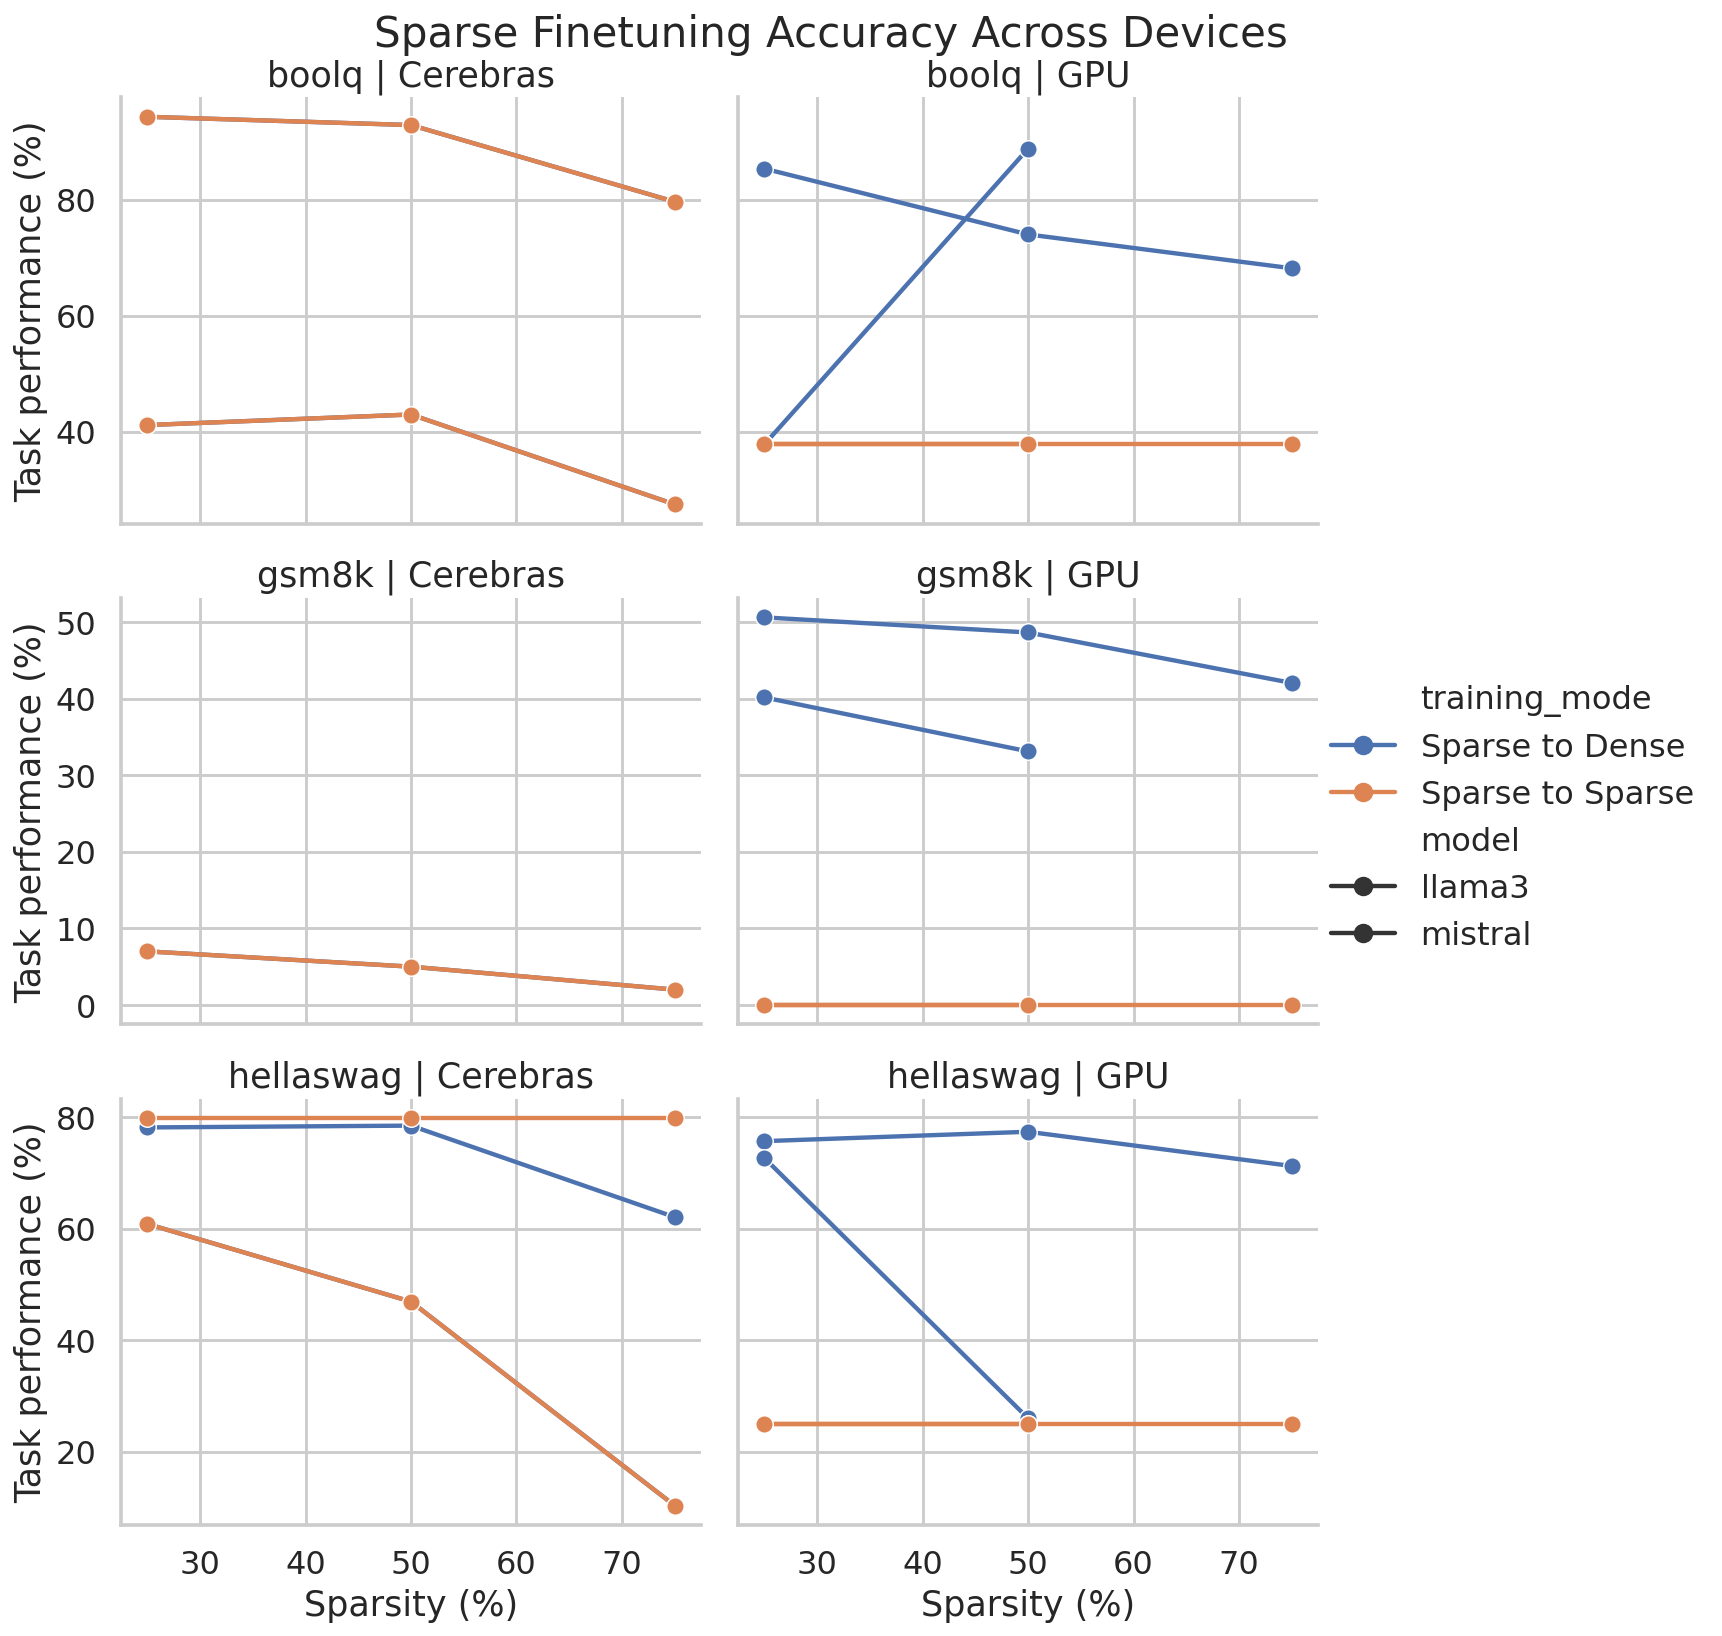

In [8]:
g = sns.relplot(
    data=acc_plot.sort_values(["task", "device", "model", "training_mode", "sparsity"]),
    x="sparsity",
    y="metric_pct",
    row="task",
    col="device",
    hue="training_mode",
    style="model",
    kind="line",
    marker="o",
    dashes=False,
    height=4.0,
    aspect=1.25,
    facet_kws={"sharey": "row"},
)
g.set_axis_labels("Sparsity (%)", "Task performance (%)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.fig.subplots_adjust(top=0.93)
g.fig.suptitle("Sparse Finetuning Accuracy Across Devices")
plt.show()

## 3) Final Training Throughput by Task, Sparsity, and Device

Rows are tasks. Columns are device types. Point annotations show the effective batch size used for that plotted throughput point.

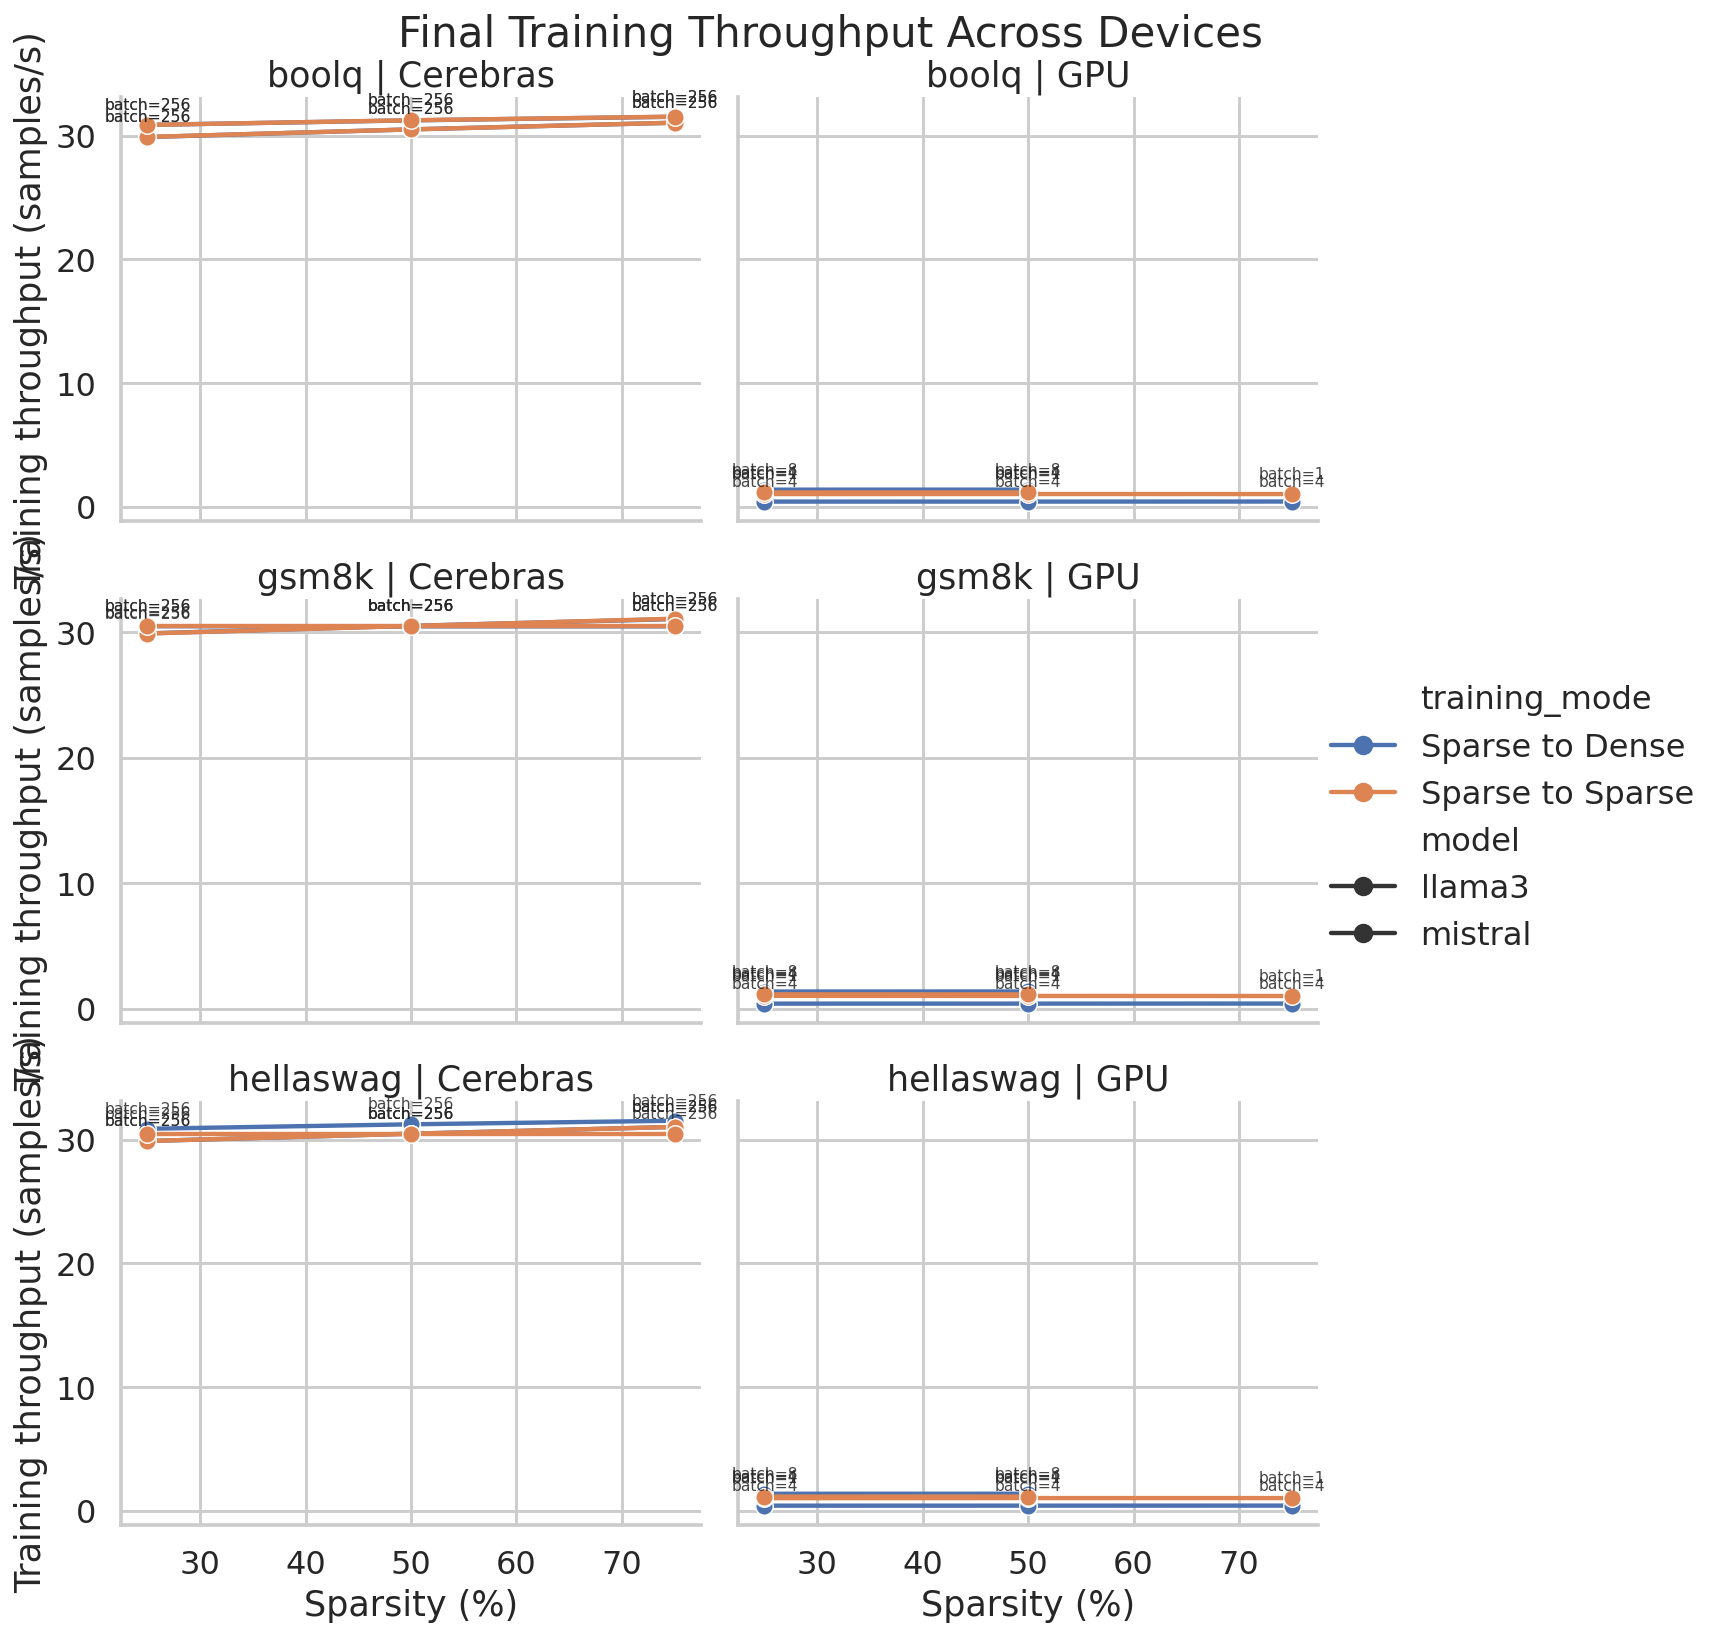

In [9]:
g = sns.relplot(
    data=final_tp_plot.sort_values(["task", "device", "model", "training_mode", "sparsity"]),
    x="sparsity",
    y="samples_per_s",
    row="task",
    col="device",
    hue="training_mode",
    style="model",
    kind="line",
    marker="o",
    dashes=False,
    height=4.0,
    aspect=1.25,
    facet_kws={"sharey": "row"},
)
g.set_axis_labels("Sparsity (%)", "Training throughput (samples/s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for (task, device), ax in g.axes_dict.items():
    subset = final_tp_plot[(final_tp_plot["task"] == task) & (final_tp_plot["device"] == device)]
    for _, row in subset.iterrows():
        ax.annotate(
            row["batch_label"],
            (row["sparsity"], row["samples_per_s"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            alpha=0.85,
        )

g.fig.subplots_adjust(top=0.93)
g.fig.suptitle("Final Training Throughput Across Devices")
plt.show()

## 4) Throughput Scaling by Task, Sparsity, and Device

This section renders one figure per sparsity level. The x-axis is effective batch size on a base-2 logarithmic scale.

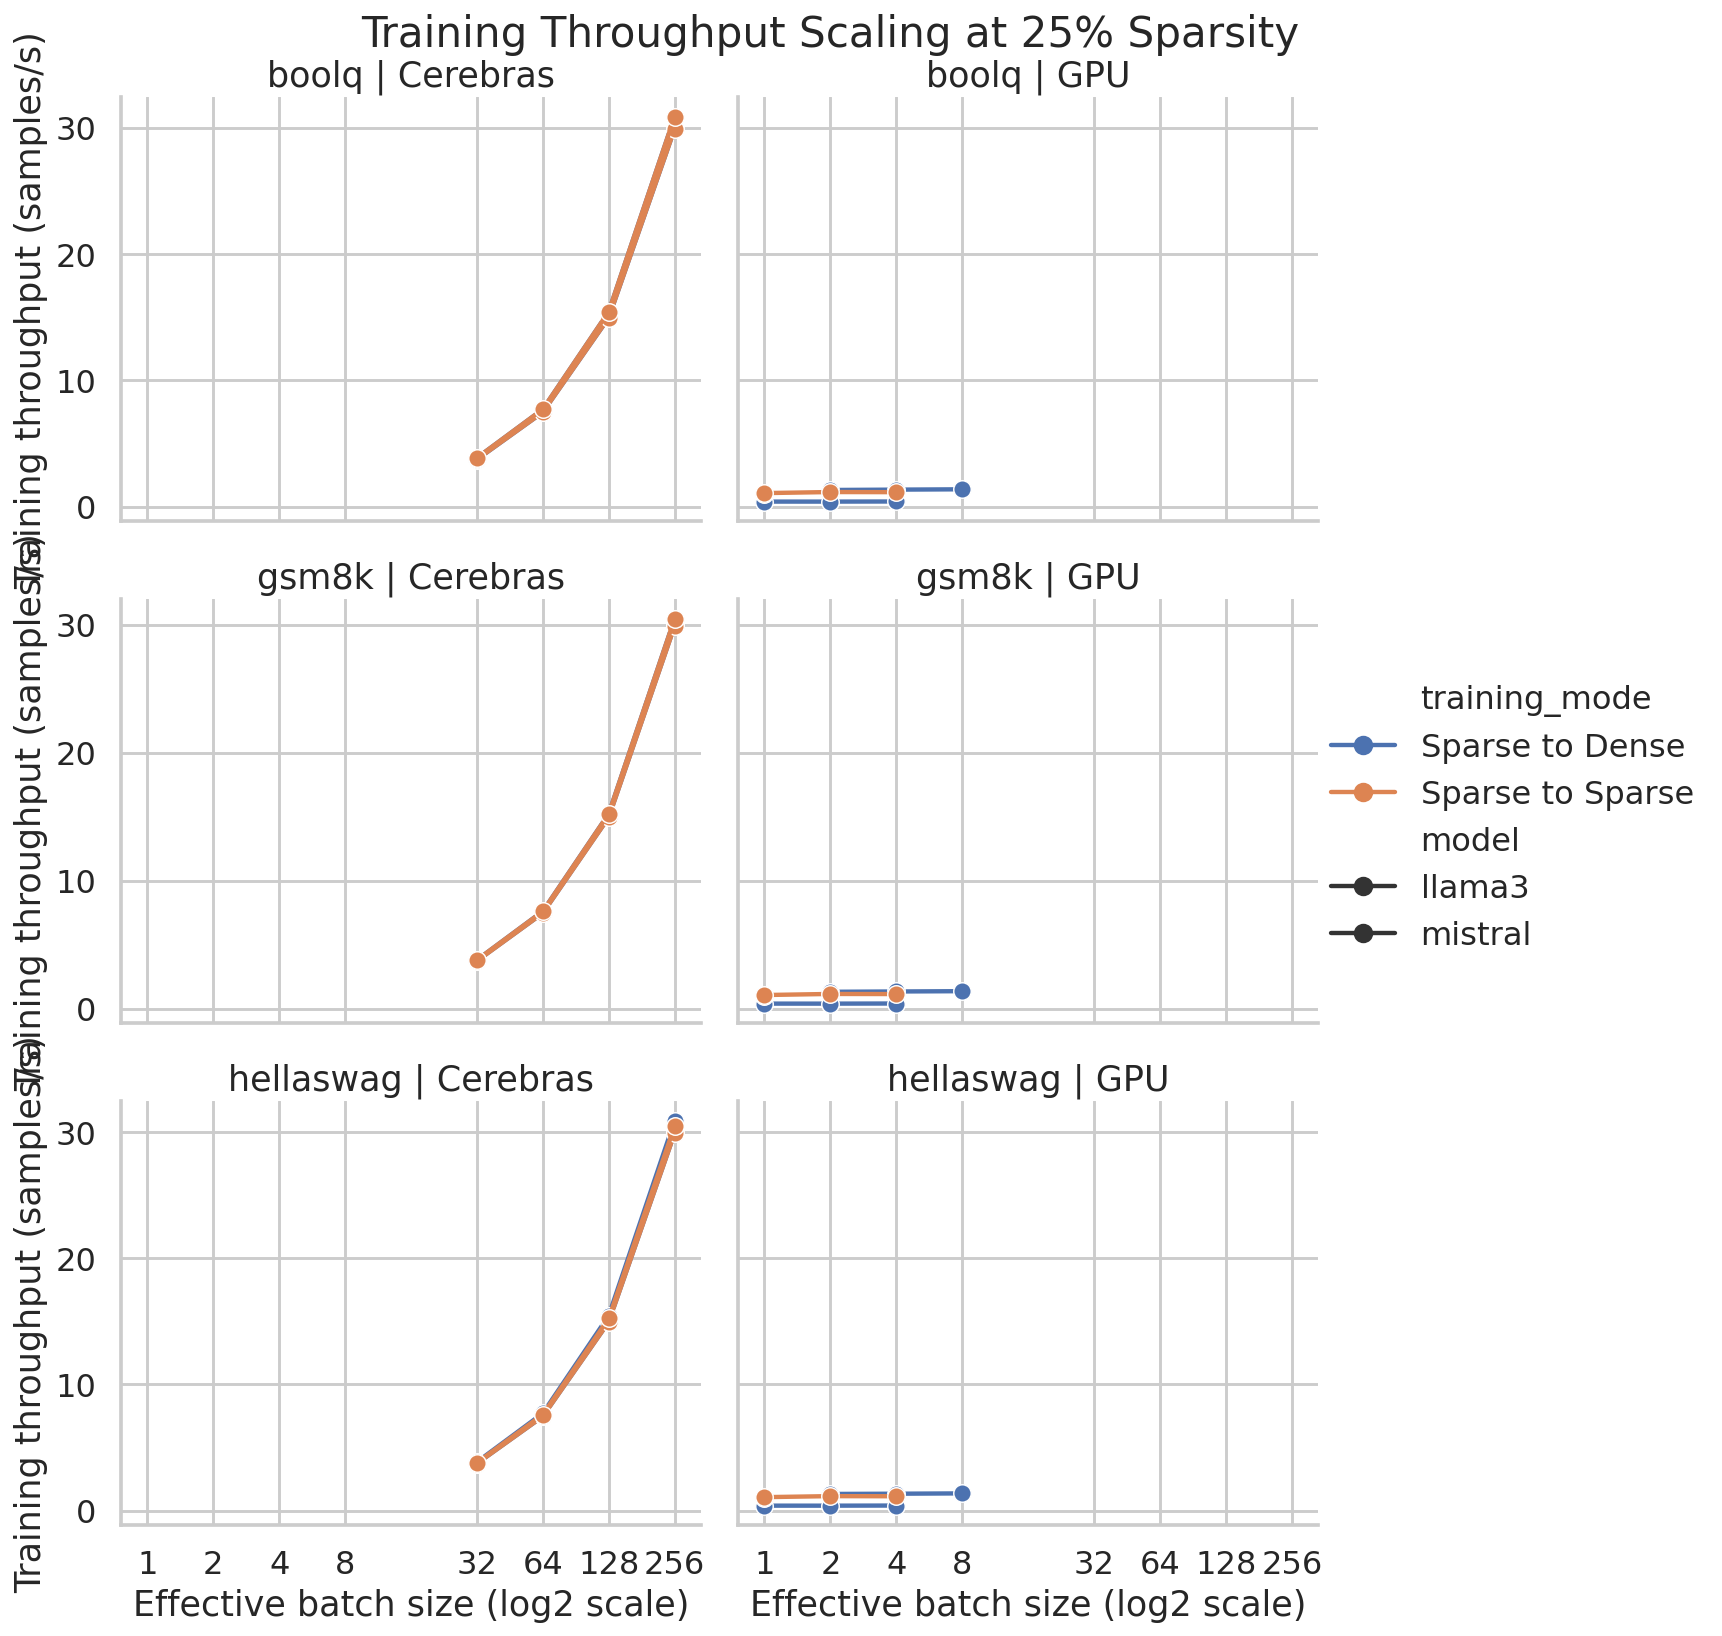

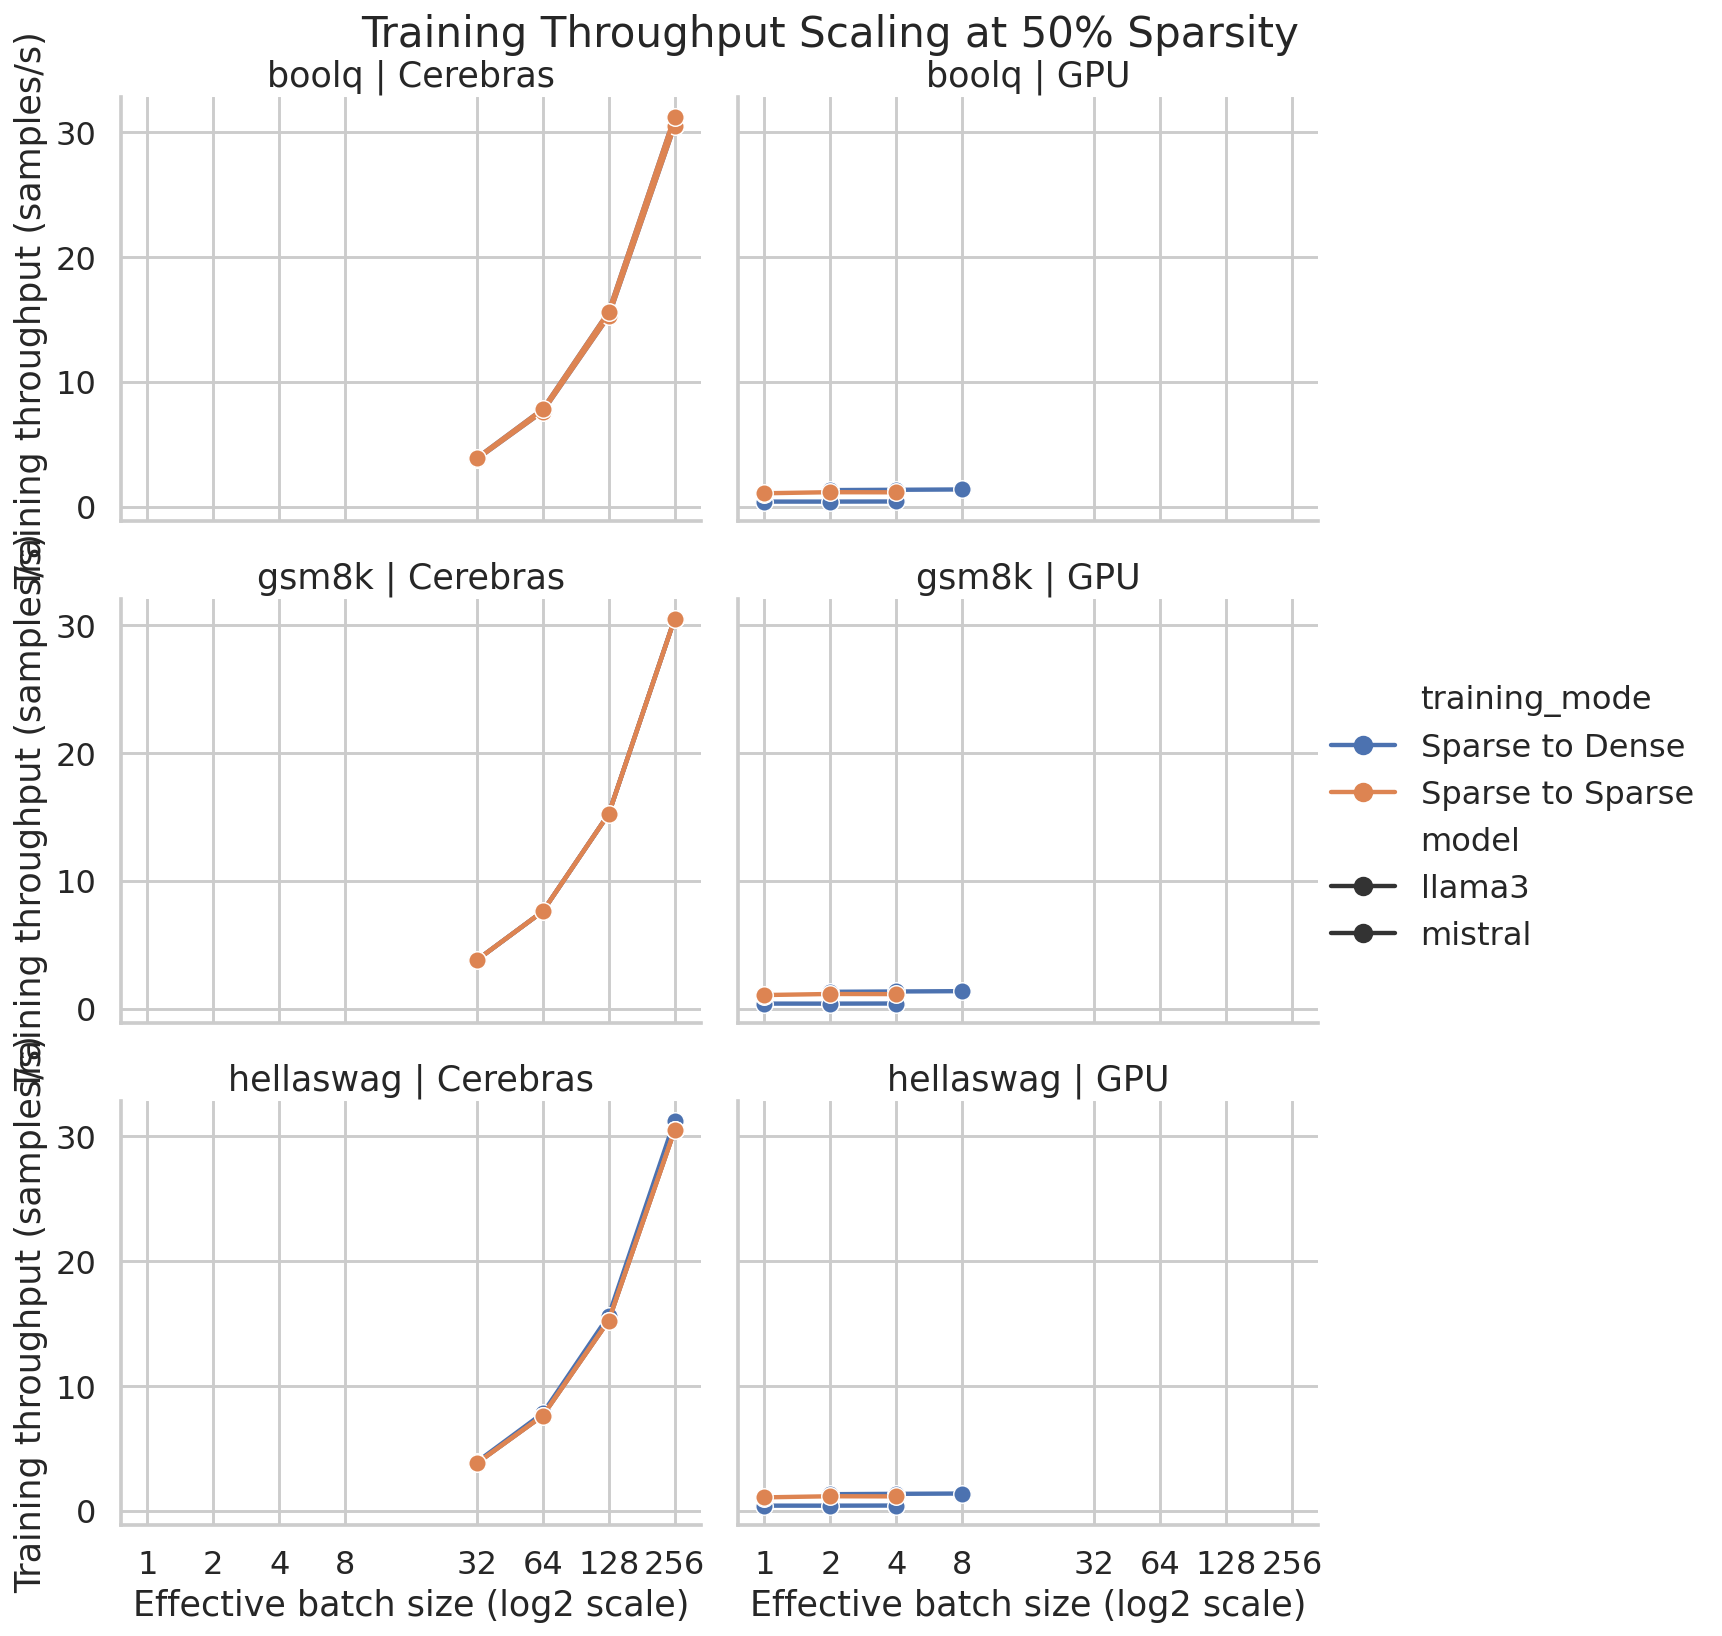

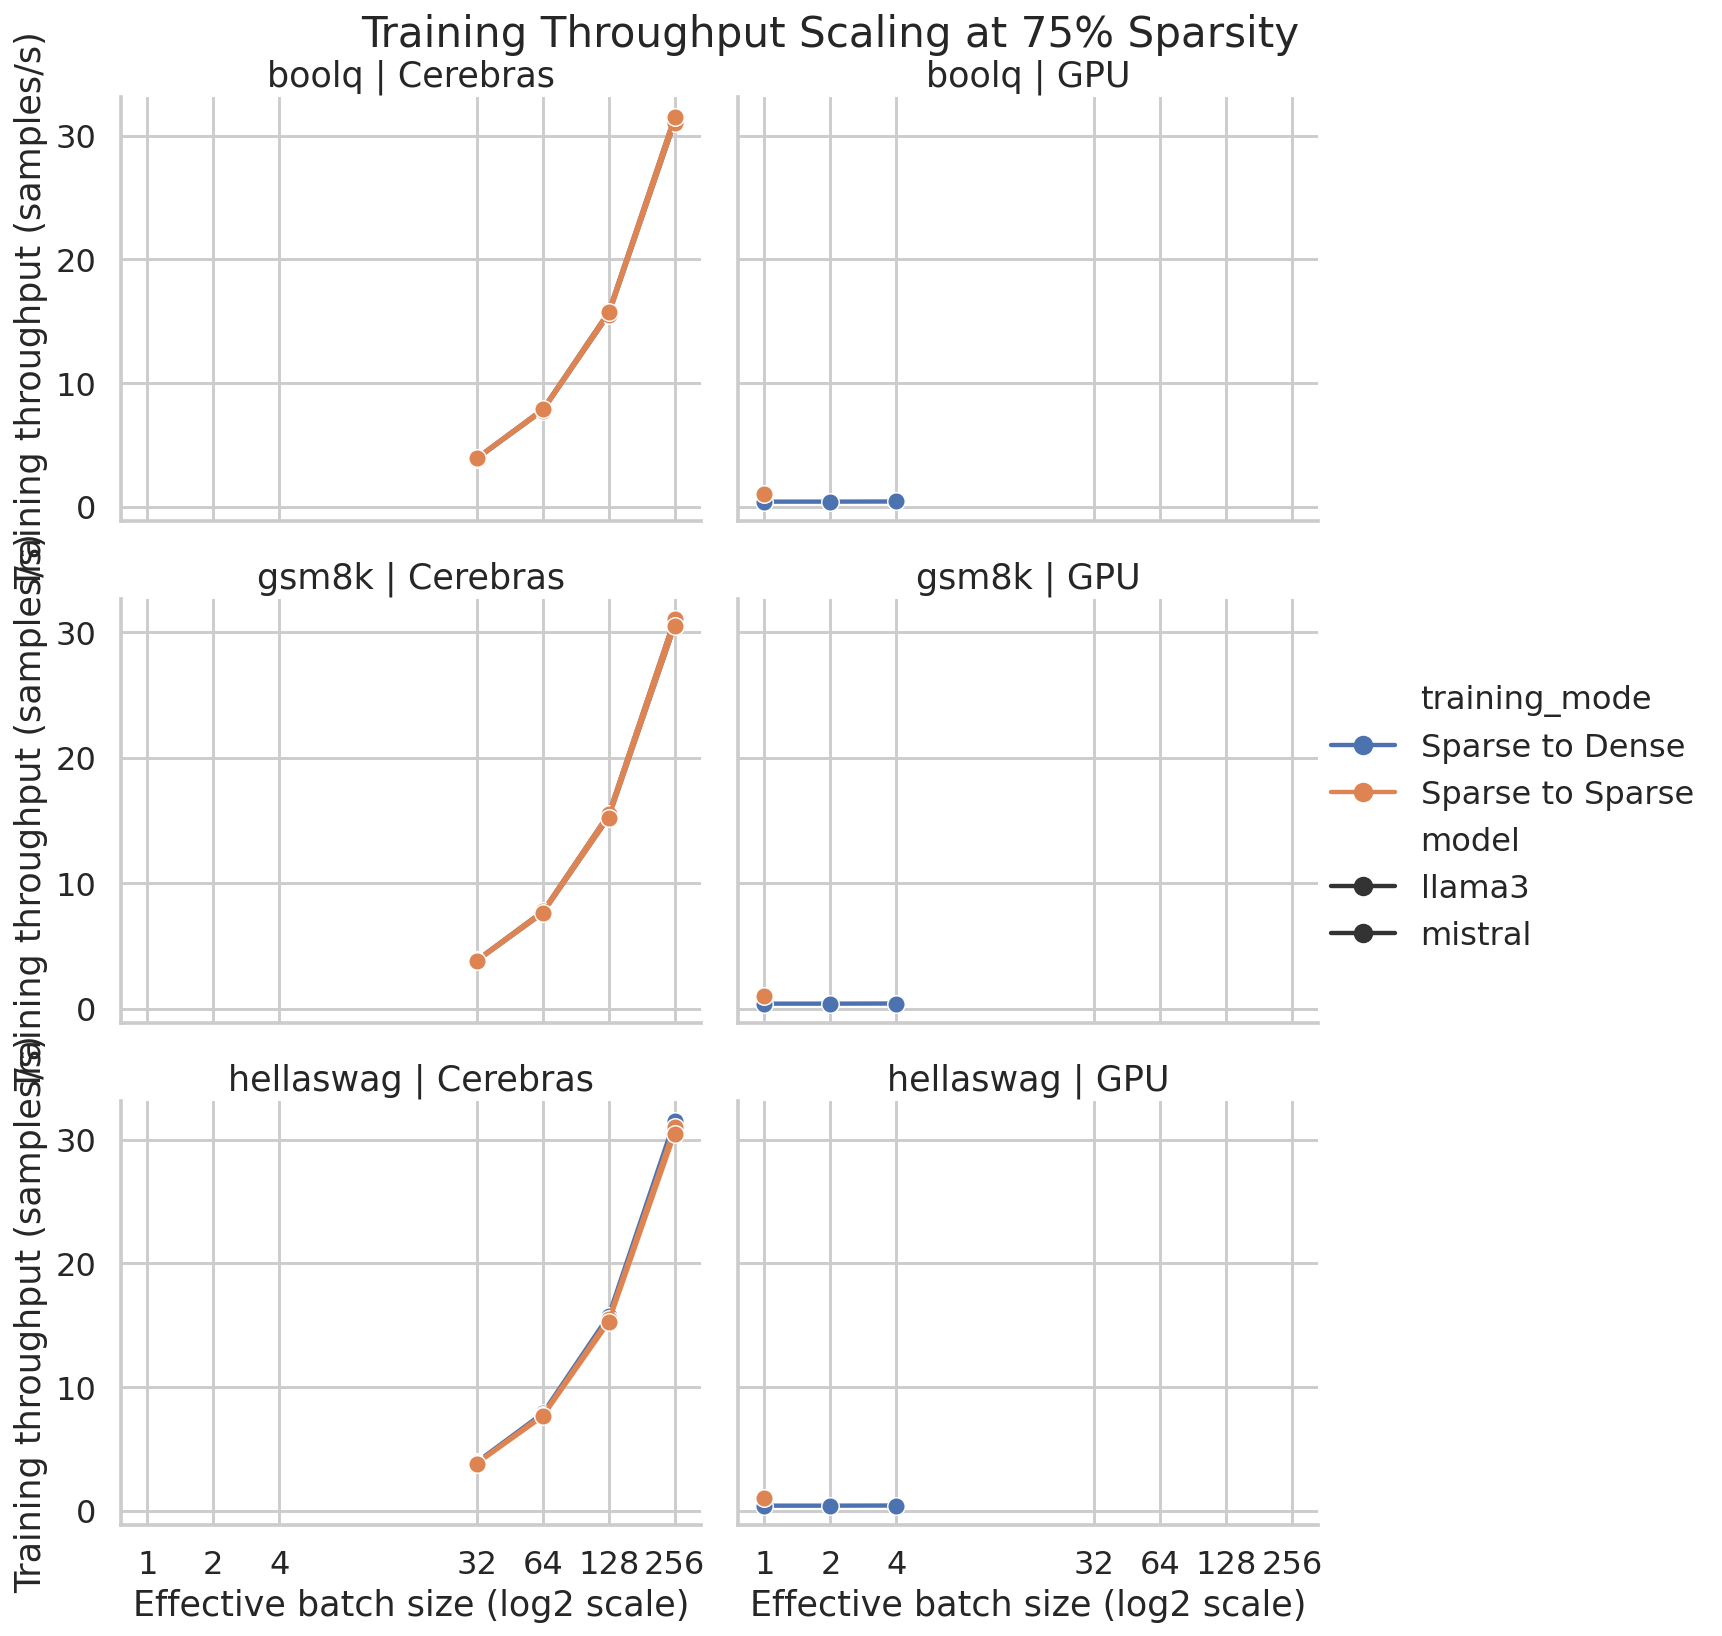

In [10]:
for sparsity in sorted(scaling_plot["sparsity"].unique()):
    subset = scaling_plot[scaling_plot["sparsity"] == sparsity].sort_values(
        ["task", "device", "model", "training_mode", "batch_size"]
    )
    g = sns.relplot(
        data=subset,
        x="batch_size",
        y="samples_per_s",
        row="task",
        col="device",
        hue="training_mode",
        style="model",
        kind="line",
        marker="o",
        dashes=False,
        height=4.0,
        aspect=1.25,
        facet_kws={"sharey": "row"},
    )
    g.set(xscale="log", xticks=sorted(subset["batch_size"].unique()))
    g.set_axis_labels("Effective batch size (log2 scale)", "Training throughput (samples/s)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flatten():
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    g.fig.subplots_adjust(top=0.93)
    g.fig.suptitle(f"Training Throughput Scaling at {sparsity}% Sparsity")
    plt.show()

## Optional: Inspect the Plotting Frames

Use these cells if you want to verify the normalized data that feeds each chart.

In [11]:
acc_plot.head()

,device,task,sparsity,metric_pct,training_mode,model,run_id
0,GPU,boolq,25,85.382263,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s2...
1,GPU,boolq,50,74.036697,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s5...
2,GPU,boolq,75,68.195719,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s7...
3,GPU,gsm8k,25,50.644428,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-gsm8k-s2...
4,GPU,gsm8k,50,48.673237,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-gsm8k-s5...


In [12]:
final_tp_plot.head()

,device,task,sparsity,samples_per_s,training_mode,model,batch_label,run_id
0,GPU,boolq,25,0.413129,Sparse to Dense,llama3,batch=4,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s2...
1,GPU,boolq,50,0.414762,Sparse to Dense,llama3,batch=4,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s5...
2,GPU,boolq,75,0.418021,Sparse to Dense,llama3,batch=4,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s7...
3,GPU,gsm8k,25,0.413561,Sparse to Dense,llama3,batch=4,gpu-week4_sparse_to_dense-llama3.1-8b-gsm8k-s2...
4,GPU,gsm8k,50,0.414931,Sparse to Dense,llama3,batch=4,gpu-week4_sparse_to_dense-llama3.1-8b-gsm8k-s5...


In [13]:
scaling_plot.head()

,device,task,sparsity,batch_size,samples_per_s,training_mode,model,run_id
0,GPU,boolq,25,4,0.413129,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s2...
1,GPU,boolq,25,2,0.403650,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s2...
2,GPU,boolq,25,1,0.404421,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s2...
3,GPU,boolq,50,4,0.414762,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s5...
4,GPU,boolq,50,2,0.405331,Sparse to Dense,llama3,gpu-week4_sparse_to_dense-llama3.1-8b-boolq-s5...
